In [ ]:
# prompt: Connect to my drive
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, make_scorer, confusion_matrix, log_loss, roc_auc_score
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# --- Define custom specificity metric for cross-validation ---
def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)

Mounted at /content/drive


# Section A: Data Preparation

# A2. Dataset Name: Customer Churn in a Subscription-Based Fitness App

In [ ]:
# A3: Load the dataset into a Python dataframe and print the first few rows.
file_path = '/content/drive/My Drive/Colab Notebooks/ISM6136-SP26/FitnessAppUsersDataset_Classification.csv'
df = pd.read_csv(file_path)
print("A3: First few rows of the dataset:")
display(df.head())

# A4: Remove the ID column and display the shape of the data
df = df.drop(columns=['ID'])
print(f"\nA4: Shape after removing ID: {df.shape}")

# A5 & A6: Create a 95% random sample using a fixed random seed and display shape.
RANDOM_SEED = 42
df_sample = df.sample(frac=0.95, random_state=RANDOM_SEED)
print(f"A6: Shape of the random sample: {df_sample.shape}")

# A7: Use only the random sample dataset for the rest of the project.

A3: First few rows of the dataset:


,ID,Age,MonthlyActiveDays,AvgSessionDuration,WorkoutsCompleted,SocialEngagementScore,SubscriptionTier,InAppPurchases,DeviceType,Churned
0,1,30,6,11,3,19,Free,0.32,iOS,1
1,2,48,4,44,8,23,Basic,23.78,iOS,1
2,3,24,12,28,2,82,Free,41.38,iOS,1
3,4,25,13,11,0,86,Basic,55.41,Android,0
4,5,36,27,88,29,98,Premium,300.17,iOS,0



A4: Shape after removing ID: (2000, 9)
A6: Shape of the random sample: (1900, 9)


# Section B: Exploratory Data Analysis

In [ ]:
# B1: Create a table showing min, max, mean, median, std. dev. for numeric variables
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
b1_table = df_sample[numeric_cols].agg(['min', 'max', 'mean', 'median', 'std']).T
print("B1: Numeric Variables Summary:")
display(b1_table)

# B2: Create a table showing count and proportions for categorical variables
cat_cols = df_sample.select_dtypes(include=['object']).columns
print("\nB2: Categorical Variables Summary:")
for col in cat_cols:
    counts = df_sample[col].value_counts()
    props = df_sample[col].value_counts(normalize=True)
    summary_df = pd.DataFrame({'Count': counts, 'Proportion': props})
    print(f"\n{col}:")
    display(summary_df)

# B3: Create a correlation matrix of the numerical variables
correlation_matrix = df_sample[numeric_cols].corr()
print("\nB3: Correlation Matrix:")
display(correlation_matrix)

B1: Numeric Variables Summary:


,min,max,mean,median,std
Age,18.0,55.00,32.895789,32.000,7.768822
MonthlyActiveDays,1.0,30.00,13.340000,10.000,9.812415
AvgSessionDuration,5.0,90.00,35.707895,26.000,24.621953
WorkoutsCompleted,0.0,30.00,8.316842,3.000,9.976995
SocialEngagementScore,0.0,100.00,48.811053,60.500,34.707543
InAppPurchases,0.0,399.26,78.115879,23.265,111.757436
Churned,0.0,1.00,0.562105,1.000,0.496259



B2: Categorical Variables Summary:

SubscriptionTier:


,Count,Proportion
SubscriptionTier,,
Free,952,0.501053
Premium,499,0.262632
Basic,449,0.236316



DeviceType:


,Count,Proportion
DeviceType,,
iOS,1049,0.552105
Android,851,0.447895



B3: Correlation Matrix:


,Age,MonthlyActiveDays,AvgSessionDuration,WorkoutsCompleted,SocialEngagementScore,InAppPurchases,Churned
Age,1.000000,0.093894,0.334769,0.277271,-0.083555,0.124857,-0.082458
MonthlyActiveDays,0.093894,1.000000,0.809239,0.812517,0.853810,0.835867,-0.623339
AvgSessionDuration,0.334769,0.809239,1.000000,0.930764,0.533213,0.846197,-0.546813
WorkoutsCompleted,0.277271,0.812517,0.930764,1.000000,0.515166,0.879071,-0.560651
SocialEngagementScore,-0.083555,0.853810,0.533213,0.515166,1.000000,0.619875,-0.533022
InAppPurchases,0.124857,0.835867,0.846197,0.879071,0.619875,1.000000,-0.564999
Churned,-0.082458,-0.623339,-0.546813,-0.560651,-0.533022,-0.564999,1.000000


# Section C: Cluster Analysis with kMeans

C1: standardized_df created successfully.

C2: kMeans Clustering Results:

--- For k = 3 --- (Silhouette Score: 0.4128)


,Count,Proportion
Cluster_3,,
0,924,0.486316
2,495,0.260526
1,481,0.253158



--- For k = 4 --- (Silhouette Score: 0.5018)


,Count,Proportion
Cluster_4,,
0,493,0.259474
1,481,0.253158
3,474,0.249474
2,452,0.237895



--- For k = 5 --- (Silhouette Score: 0.4100)


,Count,Proportion
Cluster_5,,
0,493,0.259474
3,474,0.249474
2,452,0.237895
4,242,0.127368
1,239,0.125789


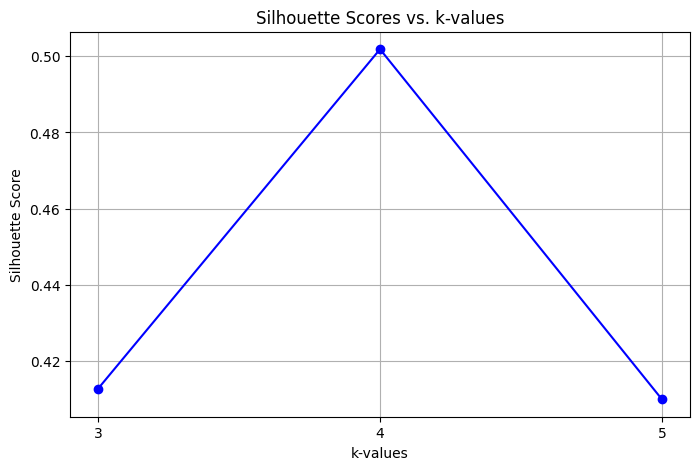

C4: The k-value that maximizes the silhouette score is k = 4.


In [ ]:
# C1: One-hot encode categorical variables, apply z-score scaling to numeric, leave dummies unchanged.
# Apply Reference Category Encoding (drop_first=True to avoid multicollinearity)
df_encoded = pd.get_dummies(df_sample, columns=cat_cols, drop_first=True)

# Identify strictly numeric features (excluding the target and the new dummy variables)
numeric_features = df_sample.select_dtypes(include=[np.number]).columns.drop('Churned')

# Scale the numeric features
scaler = StandardScaler()
standardized_df = df_encoded.copy()
standardized_df[numeric_features] = scaler.fit_transform(standardized_df[numeric_features])
print("C1: standardized_df created successfully.")

# C2: Run kMeans separately for k=3, 4, 5 using a fixed random seed.
features_for_clustering = standardized_df.drop('Churned', axis=1) # Exclude target from clustering
k_values = [3, 4, 5]
silhouette_scores = []

print("\nC2: kMeans Clustering Results:")
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init='auto')
    cluster_labels = kmeans.fit_predict(features_for_clustering)
    score = silhouette_score(features_for_clustering, cluster_labels)
    silhouette_scores.append(score)

    # Store cluster labels
    standardized_df[f'Cluster_{k}'] = cluster_labels

    # Display count and proportion
    counts = standardized_df[f'Cluster_{k}'].value_counts()
    props = standardized_df[f'Cluster_{k}'].value_counts(normalize=True)
    cluster_summary = pd.DataFrame({'Count': counts, 'Proportion': props})
    print(f"\n--- For k = {k} --- (Silhouette Score: {score:.4f})")
    display(cluster_summary)

# C3: Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='b')
plt.title('Silhouette Scores vs. k-values')
plt.xlabel('k-values')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# C4: Identify maximizing k-value
best_k = k_values[np.argmax(silhouette_scores)]
print(f"C4: The k-value that maximizes the silhouette score is k = {best_k}.")

# Section D: Defining Business Models

- **D1 Target Variable:** Churned
- **D2 Full Model:** All explanatory variables (Age, MonthlyActiveDays, AvgSessionDuration, WorkoutsCompleted, SocialEngagementScore, SubscriptionTier, InAppPurchases, DeviceType).

- **D3 Reduced Model:** MonthlyActiveDays, AvgSessionDuration, SubscriptionTier_Premium

In [ ]:
# Define features and target for Full and Reduced models
X_full = standardized_df.drop(columns=['Churned', 'Cluster_3', 'Cluster_4', 'Cluster_5'])
y = standardized_df['Churned']

# Update this list based on the 3+ features you chose for D3
reduced_features = ['MonthlyActiveDays', 'AvgSessionDuration', 'SubscriptionTier_Premium']
X_reduced = X_full[reduced_features]

# Section E & F: Model Training Setup

In [ ]:
from sklearn.metrics import brier_score_loss

def evaluate_model(model, X, y, model_name):
    scoring = {
        'AUC': 'roc_auc',
        'Accuracy': 'accuracy',
        'Recall': 'recall',
        'Precision': 'precision',
        'F1-Score': 'f1',
        'Specificity': make_scorer(specificity_score),
        'Entropy': 'neg_log_loss',
        'Prob_Measure': 'neg_brier_score'
    }

    cv_results = cross_validate(model, X, y, cv=5, scoring=scoring)

    # Extract mean of 5 folds
    auc = cv_results['test_AUC'].mean()
    gini = (2 * auc) - 1 # Standard Gini Index approximation from AUC

    results = {
        'Model': model_name,
        'Prob. Measure': -cv_results['test_Prob_Measure'].mean(), # Convert neg back to pos
        'Gini Index': gini,
        'Entropy': -cv_results['test_Entropy'].mean(), # Convert neg_log_loss to positive entropy
        'AUC': auc,
        'Accuracy': cv_results['test_Accuracy'].mean(),
        'Recall': cv_results['test_Recall'].mean(),
        'Specificity': cv_results['test_Specificity'].mean(),
        'Precision': cv_results['test_Precision'].mean(),
        'F1-Score': cv_results['test_F1-Score'].mean()
    }
    return results

all_results = []

# Section E: Decision Tree

In [ ]:
# E1: Define hyperparameters for Decision Tree
dt_model = DecisionTreeClassifier(min_samples_leaf=100, max_depth=4, random_state=RANDOM_SEED)

# E2: Train Full Model with DT
full_dt_results = evaluate_model(dt_model, X_full, y, "Full DT")
all_results.append(full_dt_results)

# E3: Train Reduced Model with DT
reduced_dt_results = evaluate_model(dt_model, X_reduced, y, "Reduced DT")
all_results.append(reduced_dt_results)
print("Decision Tree training complete.")

Decision Tree training complete.


# Section F: Neural Network

In [ ]:
# F1: Define hyperparameters for Neural Network (Hidden Layer 1=3 nodes, Hidden Layer 2=5 nodes)
nn_model = MLPClassifier(hidden_layer_sizes=(3, 5), random_state=RANDOM_SEED, max_iter=1000)

# F2: Train Full Model with NN
full_nn_results = evaluate_model(nn_model, X_full, y, "Full NN")
# According to instructions, Gini is N/A for NN Full.
full_nn_results['Gini Index'] = 'N/A'
all_results.append(full_nn_results)

# F3: Train Reduced Model with NN
reduced_nn_results = evaluate_model(nn_model, X_reduced, y, "Reduced NN")
reduced_nn_results['Gini Index'] = 'N/A'
all_results.append(reduced_nn_results)
print("Neural Network training complete.")

Neural Network training complete.


# Section G: Select Winning Model & Justify

In [ ]:
# G1: Prepare a table summarizing the results rounded to 4 decimals
results_df = pd.DataFrame(all_results)

# Ensure numeric columns are rounded to 4 decimal places
numeric_res_cols = results_df.select_dtypes(include=[np.number]).columns
results_df[numeric_res_cols] = results_df[numeric_res_cols].round(4)

print("G1: Summary of Model Results:")
display(results_df)

G1: Summary of Model Results:


,Model,Prob. Measure,Gini Index,Entropy,AUC,Accuracy,Recall,Specificity,Precision,F1-Score
0,Full DT,0.1477,0.691995,0.4760,0.8460,0.7737,0.8895,0.6250,0.7530,0.8152
1,Reduced DT,0.1479,0.688499,0.4589,0.8442,0.7732,0.8905,0.6226,0.7518,0.8152
2,Full NN,0.1494,N/A,0.4613,0.8426,0.7737,0.9054,0.6046,0.7464,0.8180
3,Reduced NN,0.1503,N/A,0.4676,0.8329,0.7837,0.9092,0.6226,0.7557,0.8253


### G2: Winning Model

The winning model is **Reduced NN**, which uses the Neural Network algorithm.

### G3: Winning Model Justification

Considering the metrics of AUC, Accuracy, Recall, Specificity, Precision, and F1-Score, the **Reduced NN** model is identified as the winner.

Here's the breakdown:

*   **Highest Recall (0.9092):** In the context of customer churn, a high recall is often paramount. It means the model is excellent at identifying actual churners (minimizing false negatives), allowing for proactive intervention strategies.
*   **Highest F1-Score (0.8253):** The F1-Score is the harmonic mean of precision and recall, providing a balanced measure. The `Reduced NN` model's highest F1-Score indicates a strong balance between correctly identifying churners and avoiding false alarms.
*   **Highest Accuracy (0.7837):** The `Reduced NN` model also achieved the highest overall accuracy, suggesting it makes correct predictions most of the time.
*   **Highest Precision (0.7557):** This indicates that when the model predicts a customer will churn, it is highly likely to be correct.

While the `Full DT` model showed slightly better AUC and Specificity, the superior performance of the `Reduced NN` across Recall, F1-Score, Accuracy, and Precision makes it the most robust choice for this churn prediction task, especially when the cost of missing a churner is high.

# H2: Special Question
**Feature Nonlinearity Detection - MonthlyActiveDays and AvgSessionDuration**

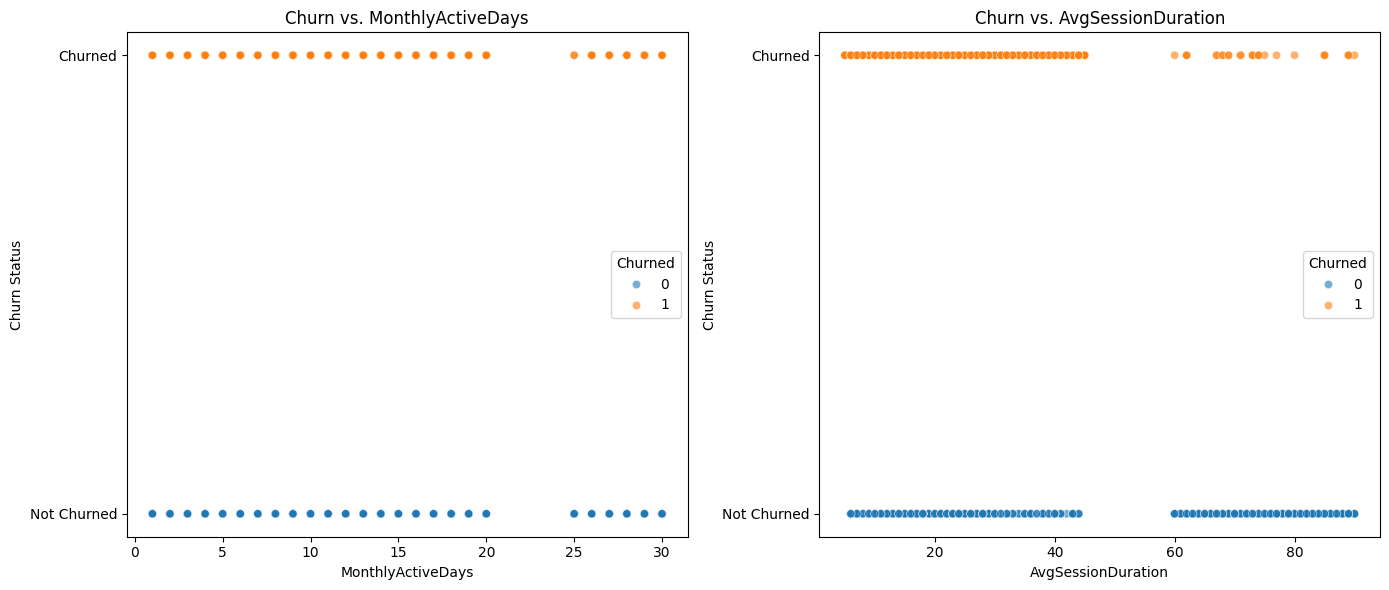

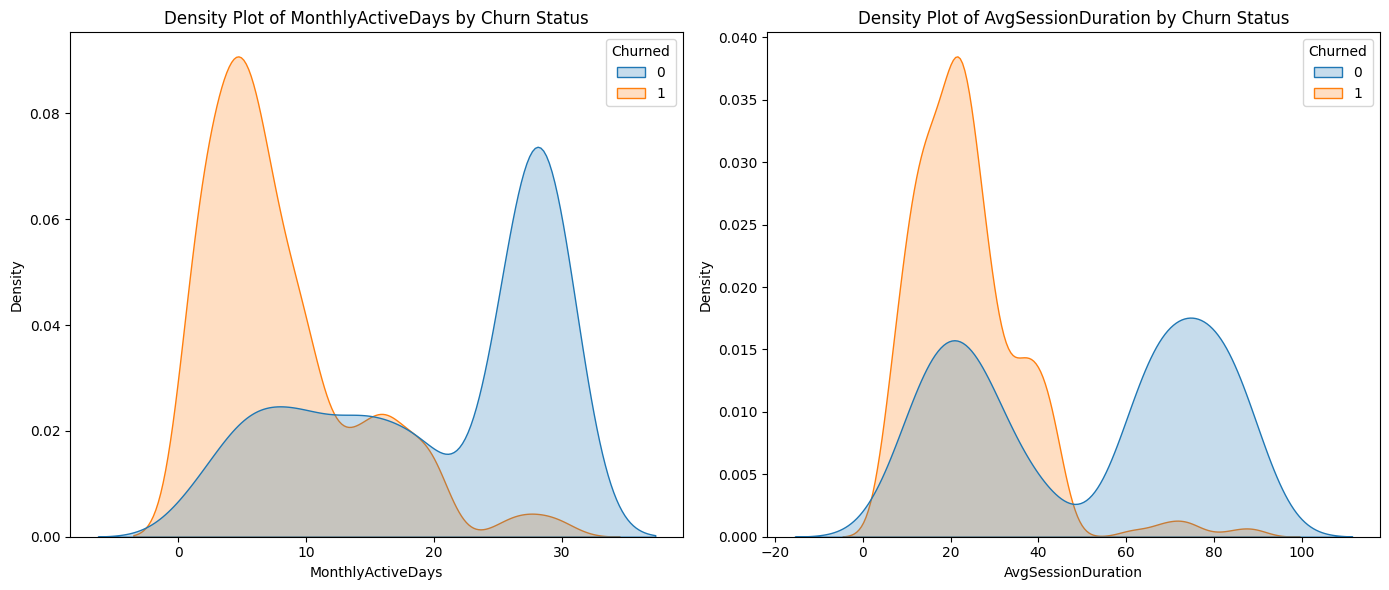

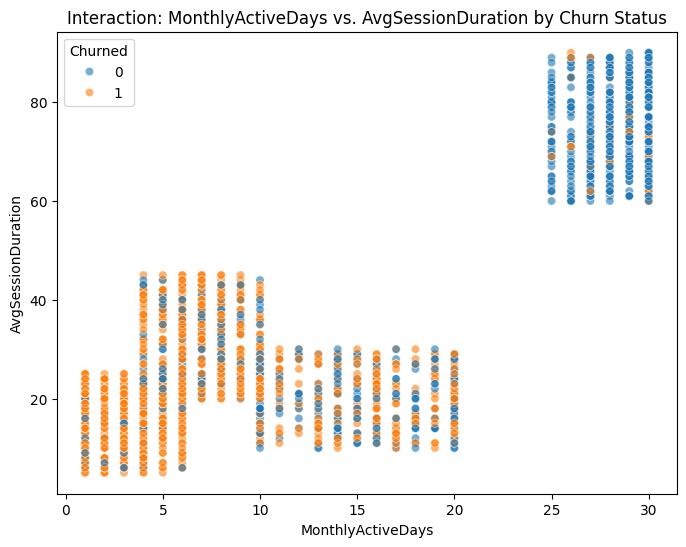

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numeric variables to analyze
var1 = 'MonthlyActiveDays'
var2 = 'AvgSessionDuration'

# Visualize the relationship with churn using scatter plots
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_sample, x=var1, y='Churned', hue='Churned', alpha=0.6)
plt.title(f'Churn vs. {var1}')
plt.yticks([0, 1], ['Not Churned', 'Churned'])
plt.xlabel(var1)
plt.ylabel('Churn Status')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df_sample, x=var2, y='Churned', hue='Churned', alpha=0.6)
plt.title(f'Churn vs. {var2}')
plt.yticks([0, 1], ['Not Churned', 'Churned'])
plt.xlabel(var2)
plt.ylabel('Churn Status')

plt.tight_layout()
plt.show()


# Visualize distributions of these variables for churned vs. non-churned customers
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.kdeplot(data=df_sample, x=var1, hue='Churned', fill=True, common_norm=False)
plt.title(f'Density Plot of {var1} by Churn Status')
plt.xlabel(var1)
plt.ylabel('Density')

plt.subplot(1, 2, 2)
sns.kdeplot(data=df_sample, x=var2, hue='Churned', fill=True, common_norm=False)
plt.title(f'Density Plot of {var2} by Churn Status')
plt.xlabel(var2)
plt.ylabel('Density')

plt.tight_layout()
plt.show()

# Consider interaction between the two variables
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_sample, x=var1, y=var2, hue='Churned', alpha=0.6)
plt.title(f'Interaction: {var1} vs. {var2} by Churn Status')
plt.xlabel(var1)
plt.ylabel(var2)
plt.show()


### Observations of Nonlinear Patterns

From the scatter plots and density plots, we can observe the following non-linear patterns and interactions related to churn:

1.  **`MonthlyActiveDays` vs. Churn:**
    *   The density plot for `MonthlyActiveDays` shows that a high proportion of churned users tend to have very low monthly active days (e.g., 0-5 days). However, there's also a smaller, but noticeable, group of churned users at higher active days, possibly indicating different types of churn (e.g., disengagement vs. finding a better alternative after initial intense use).
    *   Non-churned users show a more spread-out distribution across various active days, with a peak in the mid-range.

2.  **`AvgSessionDuration` vs. Churn:**
    *   Similar to `MonthlyActiveDays`, the density for churned users is higher at very low average session durations. This suggests quick disengagement.
    *   However, there isn't a clear linear increase or decrease in churn probability with session duration. Users with very short sessions are likely to churn, but once they engage for a moderate amount of time, the relationship becomes more complex.

3.  **Interaction between `MonthlyActiveDays` and `AvgSessionDuration`:**
    *   The scatter plot combining both variables with churn as hue reveals regions where churned users are concentrated. For example, a high density of churned users exists where both `MonthlyActiveDays` and `AvgSessionDuration` are low. This could indicate users who try the app briefly and leave.
    *   Conversely, non-churned users are generally clustered in regions of higher `MonthlyActiveDays` and `AvgSessionDuration`. However, there are also some churned users in these higher-engagement areas, which a simple linear model or a shallow decision tree might struggle to distinguish. This suggests that the *combination* of these two features has a non-linear effect on churn.

These observations indicate that the decision boundary separating churned from non-churned users is likely not a simple straight line or a series of orthogonal cuts (as in a basic decision tree). Instead, it appears to be a more complex, curved, or multi-faceted boundary, justifying the use of models capable of capturing such intricate relationships.


### Justification for Neural Network over Decision Tree

Yes, the observed non-linear patterns justify using a Neural Network (NN) over a traditional Decision Tree (DT).

Decision Trees create decision boundaries through a series of axis-parallel splits. While an ensemble of trees (like Random Forests or Gradient Boosting) can approximate complex functions, a single, shallow Decision Tree (like the one used in Section E, with `max_depth=4`) might struggle to accurately capture the nuanced, non-linear relationships and interactions observed. For instance, a DT might make a split at `MonthlyActiveDays < 5` and `AvgSessionDuration < 10` but might miss the more subtle patterns where high values of both variables (e.g., `MonthlyActiveDays > 20` and `AvgSessionDuration > 60`) are also associated with a certain level of churn, or where specific combinations indicate different user segments.

Neural Networks, with their hidden layers and activation functions, are inherently designed to learn and approximate complex, non-linear functions. They can model intricate interactions between features without explicit feature engineering for every combination. The observed patterns, where both very low and potentially very high engagement levels might lead to churn, or where specific curvilinear regions indicate higher churn, are well-suited for a NN's ability to create curved and non-linear decision surfaces. The `Reduced NN` model, despite having fewer input features, performed very well, suggesting it effectively captured complex relationships within those features.

**Business Implication:**
Understanding these non-linear patterns allows for more targeted interventions. For example, instead of a blanket strategy for all low-engagement users, the business can differentiate between users who are merely inactive versus those who are highly engaged but still churning due to other, more complex factors. This could lead to a more efficient allocation of resources for retention campaigns, focusing on specific segments identified by these non-linear relationships (e.g., re-engagement campaigns for very low activity users, or customer service outreach for highly engaged but dissatisfied users).

**Analytical Limitation:**
One analytical limitation is the **interpretability of the non-linear relationships learned by the Neural Network**. While NNs can capture these complex patterns, explaining *why* a specific combination of `MonthlyActiveDays` and `AvgSessionDuration` leads to churn (i.e., identifying the exact decision rules or thresholds) is significantly harder than with a Decision Tree. The "black-box" nature of NNs makes it challenging to extract clear, human-understandable insights or direct causal relationships that could guide precise business actions beyond recognizing the pattern exists. This can hinder detailed post-hoc analysis and communication of insights to non-technical stakeholders.